# 🧠 ML with python (Class 10): Clustering Models

Clustering is an **Unsupervised Machine Learning** technique where the goal is to group a set of objects in such a way that objects in the same group (a cluster) are more similar to each other than to those in other groups.

### 🎯 Session Agenda:
1. **Data Preparation & Environment Setup**
2. **Centroid-Based:** K-Means Clustering
3. **Connectivity-Based:** Hierarchical (Agglomerative) Clustering
4. **Density-Based:** DBSCAN (with density expansion animation)


## 1. Environment Setup & Data Generation
Let's import the necessary libraries and generate our datasets. We will use synthetic datasets because they allow us to clearly visualize how different algorithms handle specific geometric shapes and densities.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16

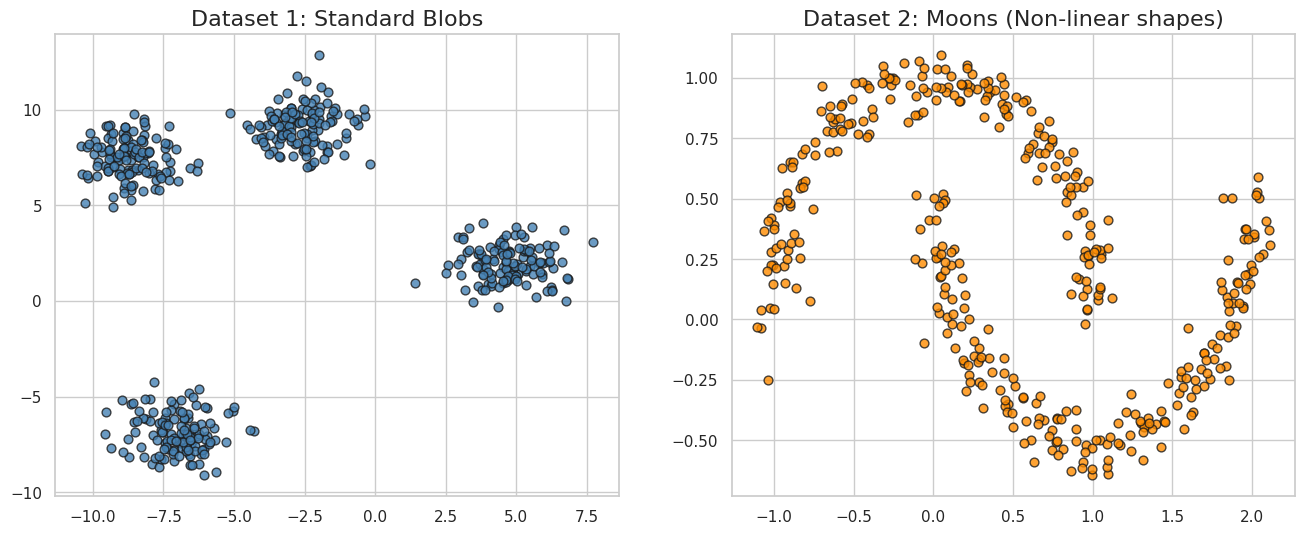

In [ ]:
from sklearn.datasets import make_blobs, make_moons

# Dataset 1: Standard Spherical Clusters (Good for K-Means)
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

# Dataset 2: Non-Spherical / Complex Shapes (Good for DBSCAN & Spectral)
X_moons, y_moons = make_moons(n_samples=400, noise=0.07, random_state=42)

# Let's visualize the datasets
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=40, c='steelblue', edgecolor='k', alpha=0.8)
ax[0].set_title('Dataset 1: Standard Blobs')

ax[1].scatter(X_moons[:, 0], X_moons[:, 1], s=40, c='darkorange', edgecolor='k', alpha=0.8)
ax[1].set_title('Dataset 2: Moons (Non-linear shapes)')

plt.show()

## 2. Centroid-Based: K-Means Clustering

**📖 Theory:**
K-Means partitions data into `K` distinct clusters. It works by:
1. Randomly initializing `K` centroids.
2. Assigning each data point to the nearest centroid.
3. Updating the centroid to the mean of all points assigned to it.
4. Repeating until convergence (centroids stop moving).

**Below is an animation showing exactly how the centroids update their positions iteratively.**

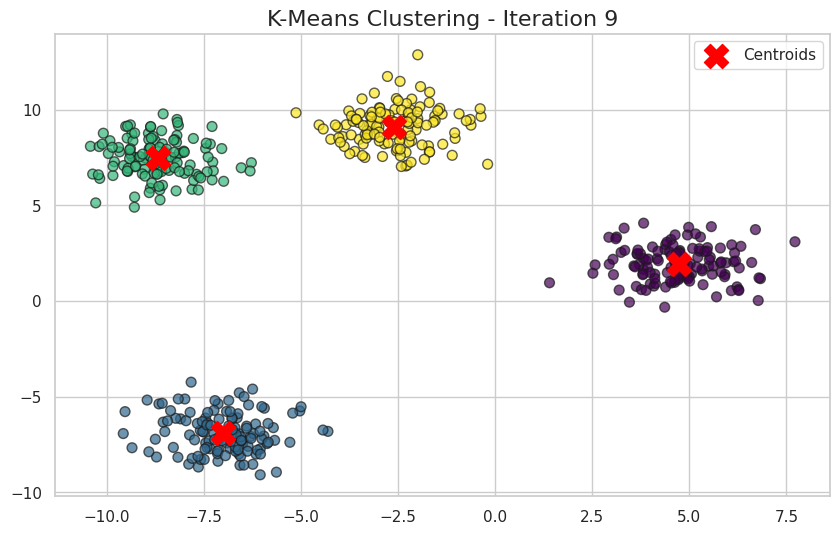

Final Silhouette Score: 0.791


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
initial_indices = np.random.choice(X_blobs.shape[0], 4, replace=False)
current_centers = X_blobs[initial_indices]

for i in range(1, 10):
    km = KMeans(n_clusters=4, init=current_centers, n_init=1, max_iter=1)
    y_km = km.fit_predict(X_blobs)
    current_centers = km.cluster_centers_

    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_km, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
    plt.scatter(current_centers[:, 0], current_centers[:, 1],
                s=300, c='red', marker='X', label='Centroids')

    plt.title(f'K-Means Clustering - Iteration {i}')
    plt.legend()
    plt.show()
    time.sleep(0.8) # Pause to create animation effect

sil_score = silhouette_score(X_blobs, y_km)
print(f"Final Silhouette Score: {sil_score:.3f}")

## 3. Connectivity-Based: Hierarchical Clustering

**📖 Theory:**
Hierarchical clustering builds a tree of clusters (a **dendrogram**). The most common approach is *Agglomerative* (bottom-up):
1. Start with each point as its own cluster.
2. Find the two closest clusters and merge them.
3. Repeat until all points are grouped into a single massive cluster.

**Below is an animation showing the "Bottom-Up" merging process, simulating moving up the dendrogram.**

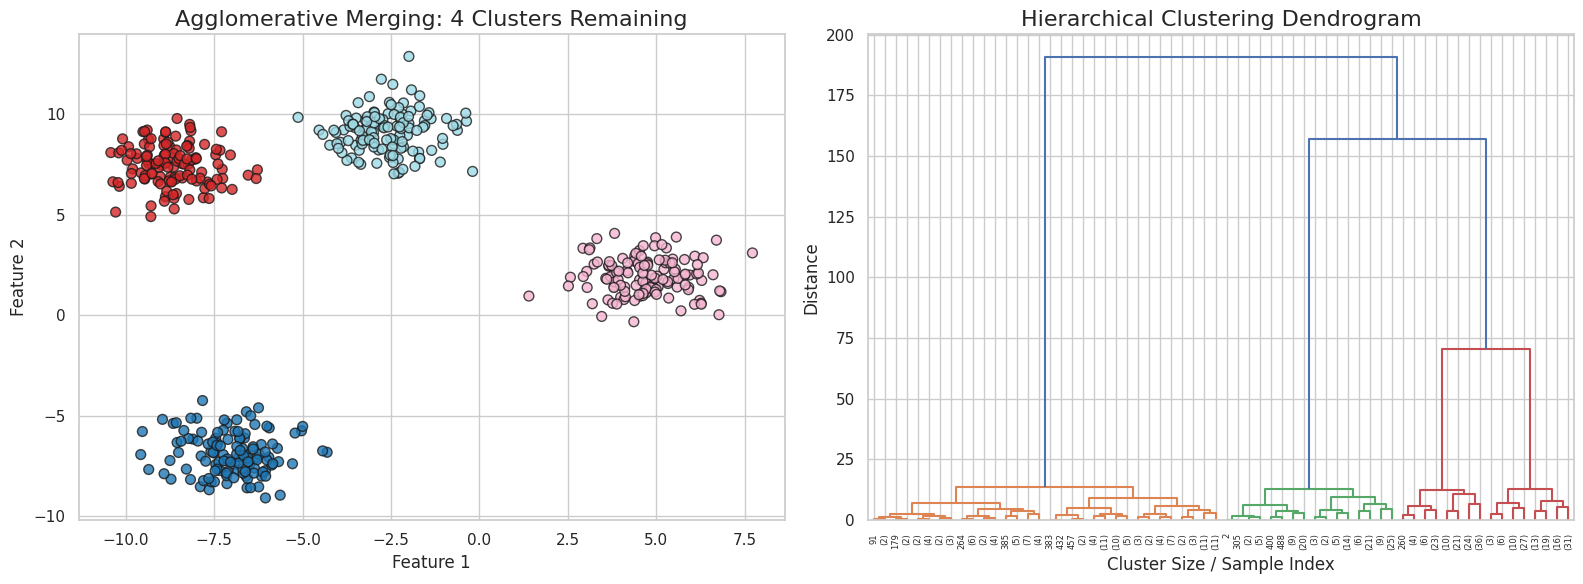

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_blobs, method='ward', metric='euclidean')

for k in range(25, 3, -1):
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    y_hc = hc.fit_predict(X_blobs)

    clear_output(wait=True)

    # Create a figure with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- LEFT PLOT: Scatter Animation ---
    ax1.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_hc, cmap='tab20', s=50, alpha=0.8, edgecolor='k')
    ax1.set_title(f'Agglomerative Merging: {k} Clusters Remaining')
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')

    # --- RIGHT PLOT: Dendrogram ---
    dendrogram(Z, ax=ax2, truncate_mode='level', p=5)
    ax2.set_title('Hierarchical Clustering Dendrogram')
    ax2.set_xlabel('Cluster Size / Sample Index')
    ax2.set_ylabel('Distance')

    plt.tight_layout()
    plt.show()
    time.sleep(0.5)

## 4. Density-Based: DBSCAN

**📖 Theory:**
DBSCAN groups points that are closely packed together and marks low-density points as outliers (noise).
* **`eps` (Epsilon):** The maximum distance between two points for them to be considered neighbors.
* **`min_samples`:** The minimum number of points required to form a "core point".

**Below is an animation showing how clusters organically expand as we gradually increase the `eps` (neighborhood radius) parameter.**

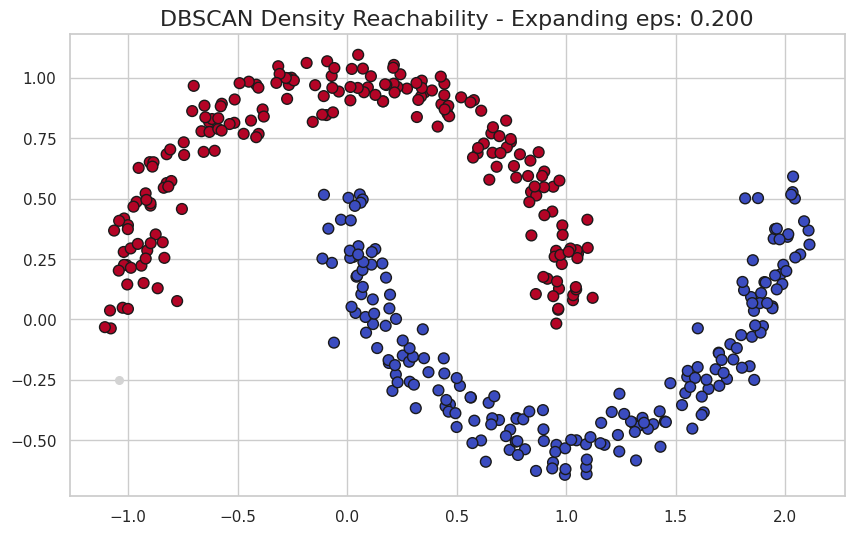

In [ ]:
from sklearn.cluster import DBSCAN

eps_values = np.linspace(0.02, 0.2, 18)

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    y_dbscan = dbscan.fit_predict(X_moons)

    clear_output(wait=True)
    plt.figure(figsize=(10, 6))

    # Plot noise points (-1) in gray
    noise_mask = (y_dbscan == -1)
    plt.scatter(X_moons[noise_mask, 0], X_moons[noise_mask, 1], c='lightgray', s=30, label='Noise')

    # Plot clustered points
    plt.scatter(X_moons[~noise_mask, 0], X_moons[~noise_mask, 1],
                c=y_dbscan[~noise_mask], cmap='coolwarm', s=60, edgecolor='k')

    plt.title(f'DBSCAN Density Reachability - Expanding eps: {eps:.3f}')
    plt.show()
    time.sleep(0.4)

## 🎉 Summary & When to use what?

| Algorithm | Primary Use Case | Geometry Assumption | Handles Outliers? | Scalability |
| :--- | :--- | :--- | :--- | :--- |
| **K-Means** | General purpose, clear boundaries | Spherical | No | Excellent |
| **Hierarchical**| Want to visualize cluster taxonomy | Spherical / Varies | No | Poor (Large Memory) |
| **DBSCAN** | Uneven shapes, lots of noise | Arbitrary | **Yes** | Good |